In [88]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

In [89]:
path = r"H:\Python\3° ETAPA\Aula 7\Tabela_13_Meio_de_transporte.xlsx"

In [90]:
df = pd.read_excel(path, skiprows=1, sheet_name=1)
df.columns = df.columns.str.strip()
print(df.columns.tolist())
print(df.columns)
df.head()

['Meio de transporte/cor ou raça', 'Branca', 'Preta ou parda', 'Indígena']
Index(['Meio de transporte/cor ou raça', 'Branca', 'Preta ou parda',
       'Indígena'],
      dtype='str')


,Meio de transporte/cor ou raça,Branca,Preta ou parda,Indígena
0,A pé,19.4,24.8,37.5
1,Bicicleta,3.2,5.2,5.9
2,Motocicleta ou Mototaxi,9.9,14.2,15.4
3,"Automóvel, taxi ou assemelhados",41.8,20.6,15.2
4,Transporte coletivo,25.2,34.6,22.4


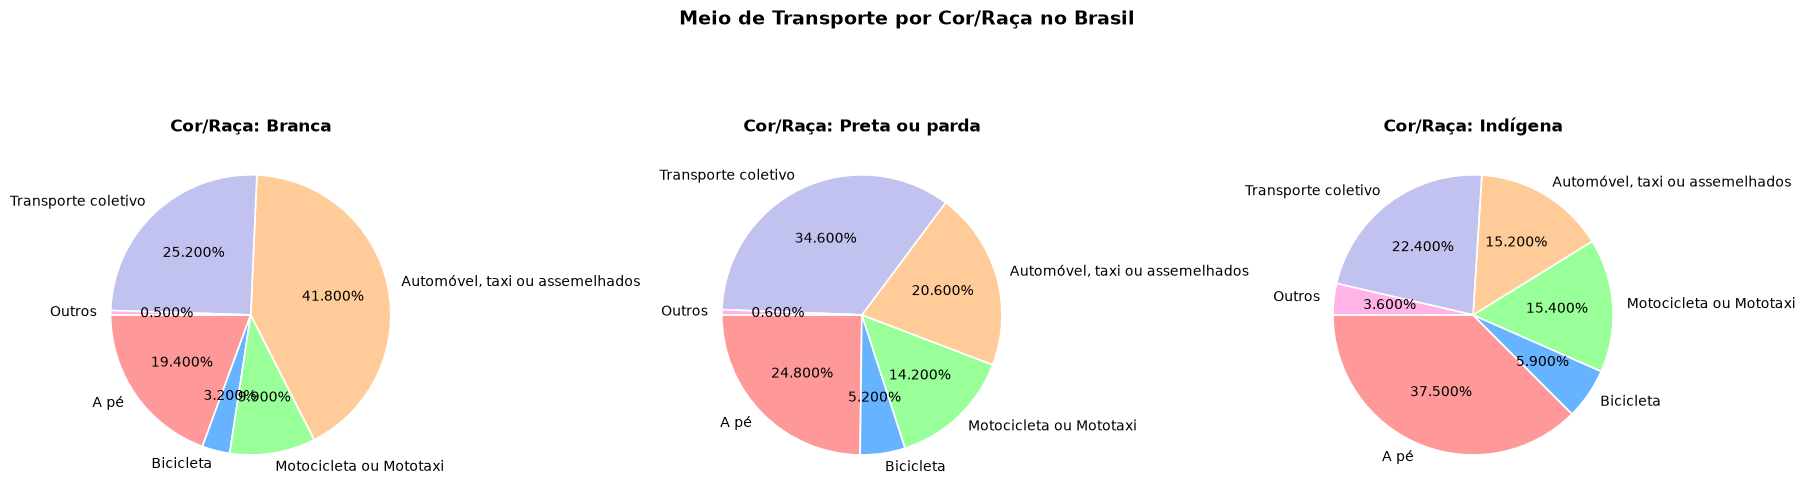

In [91]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
cores = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#c2c2f0', '#ffb3e6']
grupos = ['Branca', 'Preta ou parda', 'Indígena']

for i, col in enumerate(grupos):
    axes[i].pie(
        df[col],
        labels=df['Meio de transporte/cor ou raça'],
        autopct='%1.3f%%',
        startangle=180,
        colors=cores,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.2},
    )
    axes[i].set_title(f'Cor/Raça: {col}', fontsize=12, fontweight='bold')

plt.suptitle('Meio de Transporte por Cor/Raça no Brasil', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('grafico_transporte.png', dpi=300)
plt.show()

In [92]:
diferenca = df.set_index('Meio de transporte/cor ou raça')['Branca'] - df.set_index('Meio de transporte/cor ou raça')['Preta ou parda']
diferenca

Meio de transporte/cor ou raça
A pé                               -5.4
Bicicleta                          -2.0
Motocicleta ou Mototaxi            -4.3
Automóvel, taxi ou assemelhados    21.2
Transporte coletivo                -9.4
Outros                             -0.1
dtype: float64

# PARTE 2 


# 1 - Leia o arquivo do excel com a  aba BR GR UF MU

In [93]:
df = pd.read_excel(path, sheet_name=0, skiprows=2, header=None)
colunas = ['Local', 
           'Branca_A pé', 'Branca_Bicicleta', 'Branca_Motocicleta', 'Branca_Carro', 'Branca_Coletivo', 'Branca_Outros',
           'PretaParda_A pé', 'PretaParda_Bicicleta', 'PretaParda_Motocicleta', 'PretaParda_Carro', 'PretaParda_Coletivo', 'PretaParda_Outros',
           'Indigena_A pé', 'Indigena_Bicicleta', 'Indigena_Motocicleta', 'Indigena_Carro', 'Indigena_Coletivo', 'Indigena_Outros']
df = df.iloc[:, :19]
df.columns = colunas
df['Local'] = df['Local'].astype(str).str.strip()

# 2. Formato Longo (melt)


In [94]:
df_longo = df.melt(
    id_vars=['Local'],
    value_vars=colunas[1:],
    var_name="Categoria",
    value_name="Percentual"
)
df_longo['Percentual'] = pd.to_numeric(df_longo['Percentual'].replace(['-', ' ', '.', 'nan'], np.nan), errors='coerce').fillna(0)
df_longo[['Raca', 'Transporte']] = df_longo['Categoria'].str.split('_', expand=True)
df_geral = df_longo.groupby(['Local', 'Transporte'])['Percentual'].mean().reset_index()

# 3 - Responda as questões (com código)

In [95]:
estados = ['Rondônia', 'Acre', 'Amazonas', 'Roraima', 'Pará', 'Amapá', 'Tocantins', 'Maranhão', 'Piauí', 'Ceará', 'Rio Grande do Norte', 'Paraíba', 'Pernambuco', 'Alagoas', 'Sergipe', 'Bahia', 'Minas Gerais', 'Espírito Santo', 'Rio de Janeiro', 'São Paulo', 'Paraná', 'Santa Catarina', 'Rio Grande do Sul', 'Mato Grosso do Sul', 'Mato Grosso', 'Goiás', 'Distrito Federal']
excluir = estados + ['Brasil', 'Norte', 'Nordeste', 'Sudeste', 'Sul', 'Centro-oeste', 'nan']

df_est = df_geral[df_geral['Local'].isin(estados)]
df_cid = df_geral[~df_geral['Local'].isin(excluir)]

coletivo = df_est[df_est['Transporte'] == 'Coletivo']
print("Mais Coletivo (Estado):", coletivo.loc[coletivo['Percentual'].idxmax(), 'Local'])
print("Menos Coletivo (Estado):", coletivo.loc[coletivo['Percentual'].idxmin(), 'Local'])

bike = df_cid[df_cid['Transporte'] == 'Bicicleta']
print("Mais Bicicleta (Cidade):", bike.loc[bike['Percentual'].idxmax(), 'Local'])

carro = df_cid[df_cid['Transporte'] == 'Carro']
print("Mais Carro (Cidade):", carro.loc[carro['Percentual'].idxmax(), 'Local'])

Mais Coletivo (Estado): Rio de Janeiro
Menos Coletivo (Estado): Rondônia
Mais Bicicleta (Cidade): Lagoa Grande (MG)
Mais Carro (Cidade): Bom Jesus (SC)
